In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, kruskal, mannwhitneyu
from scipy.stats import f_oneway
from itertools import combinations
import seaborn as sns
from factor_analyzer import FactorAnalyzer
import glob
import pingouin as pg
from scipy.stats import ttest_ind 
import pyxdf
import re
from dfExtractor import extract_all_streams_to_dataframes


In [ ]:
def get_gaze_data(filepath = "/home/mitchell/Documents/Projects/P8-Project/Dataprocessing Pipeline/Test_Data/ses-13/sub-13_ses-13_task-Baseline/_.xdf"):
    try:
        streams, header = pyxdf.load_xdf(filepath)
    except Exception as e:
        print(f"Error loading XDF file {filepath}: {e}")
        return None, None
    gaze_stream = next((s for s in streams if s["info"]["name"][0] == "GazePointStream"), None)
    if gaze_stream:
        gaze_data = gaze_stream['time_series']
        gaze_ts = gaze_stream['time_stamps']
        return gaze_data, gaze_ts
    else:
        print(f"Warning: Gaze stream not found in {filepath}.")
        return None, None

gaze_data, gaze_ts = get_gaze_data()
# convert to DataFrame with time stamps in one axis and the object being looked at in the other axis
#gaze_df = pd.DataFrame({'time': gaze_ts, 'layer': [l[0] for l in gaze_data]})
# print each unique layer
#print(gaze_df["layer"].unique())

Error loading XDF file /home/mitchell/Documents/Projects/P8-Project/Dataprocessing Pipeline/Test_Data/ses-13/sub-13_ses-13_task-Baseline/_.xdf: file \home\mitchell\Documents\Projects\P8-Project\Dataprocessing Pipeline\Test_Data\ses-13\sub-13_ses-13_task-Baseline\_.xdf does not exist.


In [9]:
#DrinkPerformanceMetrics
def get_performance_metrics(filepath):
    try:
        streams, header = pyxdf.load_xdf(filepath)
    except Exception as e:
        print(f"Error loading XDF file {filepath}: {e}")
        return None, None
    performance_stream = next((s for s in streams if s["info"]["name"][0] == "DrinkPerformanceMetrics"), None)
    if performance_stream:
        performance_data = performance_stream['time_series']
        performance_ts = performance_stream['time_stamps']
        return performance_data, performance_ts
    else:
        print(f"Warning: Performance stream not found in {filepath}.")
        return None, None

In [21]:
# --- Main Data Loading Loop ---
all_loaded_data = [] # Stores dictionaries of {metadata, streams_dict}

data_root_folder = os.path.join(os.getcwd(), "Test_Data") # Ensure this path is correct
if not os.path.isdir(data_root_folder):
    print(f"Error: Data root folder not found at {data_root_folder}")
    # Depending on the notebook flow, you might want to stop execution here
    # For now, it will proceed and likely find no session folders.

session_folders = [f.path for f in os.scandir(data_root_folder) if f.is_dir() and re.match(r'ses-\d+', f.name)]

if not session_folders:
    print(f"No session folders (e.g., 'ses-01') found in {data_root_folder}.")

for session_folder_path in session_folders:
    session_name = os.path.basename(session_folder_path)
    print(f"Processing session: {session_name}")

    subject_task_folders = [
        f.path for f in os.scandir(session_folder_path)
        if f.is_dir() and "sub-" in f.name and "_task-" in f.name
    ]

    if not subject_task_folders:
        print(f"  No subject-task folders found in {session_name}.")
        continue

    for st_folder_path in subject_task_folders:
        st_folder_name = os.path.basename(st_folder_path)
        
        match_sub = re.search(r'(sub-([^_\\s]+))', st_folder_name)
        if not match_sub:
            print(f"    Warning: Could not parse subject ID from folder name {st_folder_name}. Skipping.")
            continue
        # subject_id_full_str = match_sub.group(1) # e.g. "sub-13"
        subject_id_cleaned = match_sub.group(2)  # e.g. "13"
        
        match_task = re.search(r'_task-([^_\\s]+)', st_folder_name)
        if not match_task:
            print(f"    Warning: Could not parse task type from folder name {st_folder_name}. Skipping.")
            continue
        task_type = match_task.group(1)

        if task_type.lower() == 'baseline': # Skip baseline tasks as per previous requirement
            # print(f"    Skipping baseline task folder: {st_folder_name}") # Optional log
            continue
        
        print(f"  Processing folder: {st_folder_name} (Subject: {subject_id_cleaned}, Task: {task_type})")

        xdf_files_in_folder = glob.glob(os.path.join(st_folder_path, "*.xdf"))

        if not xdf_files_in_folder:
            print(f"    Warning: No XDF file found in folder {st_folder_name}. Skipping.")
            continue
        
        # If multiple XDF files, process all or just the first? For now, just the first.
        if len(xdf_files_in_folder) > 1:
            print(f"    Warning: Multiple XDF files found in {st_folder_name}. Using the first one: {os.path.basename(xdf_files_in_folder[0])}.")
        
        current_xdf_file = xdf_files_in_folder[0]
        print(f"    Loading XDF file: {os.path.basename(current_xdf_file)}")

        all_streams_dict = extract_all_streams_to_dataframes(current_xdf_file)

        if not all_streams_dict:
            print(f"    Warning: No streams extracted from {os.path.basename(current_xdf_file)} for subject {subject_id_cleaned}, task {task_type}.")
            # continue # Decide if you want to skip adding an entry if no streams are found
        
        loaded_entry = {
            "session": session_name,
            "subject_id": subject_id_cleaned,
            "task_type": task_type,
            "file_path": current_xdf_file,
            "streams_data": all_streams_dict if all_streams_dict else {} # Store empty dict if extraction failed
        }
        all_loaded_data.append(loaded_entry)
        
        if all_streams_dict:
            print(f"    Successfully loaded {len(all_streams_dict)} streams for subject {subject_id_cleaned}, task {task_type}.")
            # print(f"      Streams found: {list(all_streams_dict.keys())}") # Optional: list stream names
        

if not all_loaded_data:
    print("\nNo data was loaded from any XDF files.")
else:
    print(f"\n--- Data Loading Complete ---")
    print(f"Total entries loaded: {len(all_loaded_data)}")
    if len(all_loaded_data) > 0:
        print(f"Example of first loaded entry keys: {all_loaded_data[0].keys()}")
        print(f"Streams in first entry: {list(all_loaded_data[0]['streams_data'].keys()) if all_loaded_data[0]['streams_data'] else 'No streams'}")

# At this point, 'all_loaded_data' is a list of dictionaries.
# Each dictionary contains metadata and the 'streams_data' (which is the output of extract_all_streams_to_dataframes).
# You can now iterate through 'all_loaded_data' to perform specific analyses on the streams.

# Example of accessing data for later analysis:
# for entry in all_loaded_data:
#     print(f"\nAnalyzing data for Subject: {entry['subject_id']}, Task: {entry['task_type']}, Session: {entry['session']}")
#     gaze_df = entry['streams_data'].get('GazePointStream')
#     if gaze_df is not None:
#         print(f"  GazePointStream data found with {len(gaze_df)} rows.")
#         # ... further processing of gaze_df ...
#     else:
#         print("  GazePointStream not found in this entry.")

Processing session: ses-10
  Processing folder: sub-10_ses-10_task-Baseline (Subject: 10, Task: Ba)
    Loading XDF file: _.xdf
    Successfully loaded 4 streams for subject 10, task Ba.
  Processing folder: sub-10_ses-10_task-MediumFi (Subject: 10, Task: MediumFi)
    Loading XDF file: _.xdf
    Successfully loaded 3 streams for subject 10, task MediumFi.
Processing session: ses-11
  Processing folder: sub-11_ses-11_task-Baseline (Subject: 11, Task: Ba)
    Loading XDF file: _.xdf
    Successfully loaded 3 streams for subject 11, task Ba.
  Processing folder: sub-11_ses-11_task-LowFi (Subject: 11, Task: LowFi)
    Loading XDF file: _.xdf
    Successfully loaded 2 streams for subject 11, task LowFi.
Processing session: ses-12
  Processing folder: sub-12_ses-12_task-Baseline (Subject: 12, Task: Ba)
    Loading XDF file: _.xdf
    Successfully loaded 3 streams for subject 12, task Ba.
  Processing folder: sub-12_ses-12_task-MediumFi (Subject: 12, Task: MediumFi)
    Loading XDF file: _.x


Analyzing data for Subject: 10, Task: MediumFi, Session: ses-10
  GazePointStream data found with 18303 rows.
Index([85260.51821052581, 85260.51822222582, 85265.08569633997,
       85265.09959294002,  85265.1260643401, 85265.13999624015,
       85265.16799424024, 85265.18165944028, 85265.20953424036,
       85265.22392114041,
       ...
       85808.34377422552, 85808.35959602558, 85808.38298872566,
        85808.3982222257, 85808.42021032577, 85808.44446332584,
       85808.46063232589, 85808.47893922594, 85808.49777262601,
       85808.52124302607],
      dtype='float64', name='Timestamp', length=18303)


TypeError: unhashable type: 'numpy.ndarray'

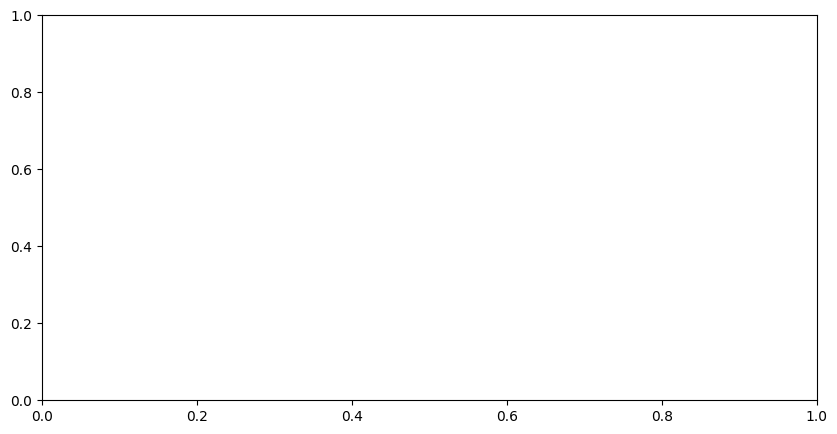

In [ ]:
for entry in all_loaded_data:
    if entry['task_type'].lower() != 'ba':
        print(f"\nAnalyzing data for Subject: {entry['subject_id']}, Task: {entry['task_type']}, Session: {entry['session']}")
        gaze_df = entry['streams_data'].get('GazePointStream')
        if gaze_df is not None:
            print(f"  GazePointStream data found with {len(gaze_df)} rows.")
            #print(gaze_df.index)
            plt.figure(figsize=(10, 5))
            plt.xlabel('Time (s)')
            plt.ylabel('Layer')
            plt.show()

In [ ]:

metrics_list = [
    "ideal_ingredient_count",
    "actual_ingredient_count",
    "wrong_ingredients_count",
    "overpour",
    "underpour",
    "pour_deviation",
    "total_score",
    "correct_glass",
    "mishandled_ingredient_count",
    "sum_ideal_amount",
    "sum_actual_amount",
    "time_taken"
]
def get_performance_metrics_dataframe(file_path):
    session_performance_Df = pd.DataFrame()  # Initialize an empty DataFrame to store global performance data
    performance_data, performance_ts = get_performance_metrics(file_path)
    if performance_data is not None and performance_ts is not None and performance_data.size > 0 and performance_ts.size > 0:
        print(f"Processing file: {file_path}")
        if performance_data.size > 0:
            performance_df = pd.DataFrame(performance_data, columns=metrics_list)
            participant_id = int(file_path.split("\\")[1].split("-")[1])  # Extract participant ID from the filepath
            performance_df['participant_id'] = participant_id  # Add participant ID to the dataframe
            # Determine the group based on the task type in the file path
            task_type = file_path.split("_task-")[1].split("\\")[0]
            print(f"Task type: {task_type}")
            if "HighFi" in task_type:
                group = "C"
            elif "MidFi" in task_type:
                group = "B"
            elif "LowFi" in task_type:
                group = "A"
            else:
                group = "Unknown"
            print(f"Group: {group}")
            performance_df['Group'] = group 
            session_performance_Df = performance_df.copy()
    return session_performance_Df


In [11]:
xdf_folder_path = "Test_Data1\\"
for root, dirs, files in os.walk(xdf_folder_path):
    for subdir in dirs:
        if "-Baseline" not in subdir:
            subfolder_path = os.path.join(root, subdir)
            xdf_files = glob.glob(os.path.join(subfolder_path, "*.xdf"))
            for xdf_file in xdf_files:
                performance_data = get_performance_metrics_dataframe(xdf_file)



Processing file: Test_Data1\ses-02\sub-2_ses-2_task-HighFi\sub-2_ses-1_task-HighFi_.xdf
Task type: HighFi
Group: C
Processing file: Test_Data1\ses-04\sub-4_ses-4_task-HighFi\sub-4_ses-1_task-HighFi_.xdf
Task type: HighFi
Group: C


Stream 1: Segments and clock-segments differ


Processing file: Test_Data1\ses-07\sub-7_ses-7_task-LowFi\_.xdf
Task type: LowFi
Group: Unknown
Processing file: Test_Data1\ses-09\sub-9_ses-9_task-MediumFi\_.xdf
Task type: MediumFi
Group: Unknown


Stream 2: Segments and clock-segments differ


Processing file: Test_Data1\ses-10\sub-10_ses-10_task-MediumFi\_.xdf
Task type: MediumFi
Group: Unknown
Processing file: Test_Data1\ses-11\sub-11_ses-11_task-LowFi\_.xdf
Task type: LowFi
Group: Unknown
Processing file: Test_Data1\ses-12\sub-12_ses-12_task-MediumFi\_.xdf
Task type: MediumFi
Group: Unknown
Processing file: Test_Data1\ses-17\sub-17_ses-1_task-LowFi\_.xdf
Task type: LowFi
Group: Unknown
Processing file: Test_Data1\ses-18\sub-18_ses-1_task-HighFi\_.xdf
Task type: HighFi
Group: C


Stream 1: Segments and clock-segments differ


Processing file: Test_Data1\ses-21\sub-21_ses-1_task-HighFi\_.xdf
Task type: HighFi
Group: C
Processing file: Test_Data1\ses-23\sub-23_ses-23_task-HighFi\_.xdf
Task type: HighFi
Group: C


Stream 1: Segments and clock-segments differ


Processing file: Test_Data1\ses-24\sub-24_ses-24_task-HighFi\_.xdf
Task type: HighFi
Group: C


Stream 4: Segments and clock-segments differ


Processing file: Test_Data1\ses-02\sub-2_ses-2_task-HighFi\sub-2_ses-1_task-HighFi_.xdf
Task type: HighFi
Group: C
Performance data:    ideal_ingredient_count  actual_ingredient_count  wrong_ingredients_count  \
0                     5.0                      2.0                      1.0   
1                     5.0                      4.0                      1.0   
2                     7.0                      3.0                      0.0   

     overpour  underpour  pour_deviation  total_score  correct_glass  \
0    0.000000  12.599808       12.599808     0.000000            1.0   
1  125.199997   0.000000      125.199997     7.775391            0.0   
2   10.200001  15.393333       25.593334    58.947571            1.0   

   mishandled_ingredient_count  sum_ideal_amount  sum_actual_amount  \
0                          1.0             180.0         322.200378   
1                          3.0              32.0         157.400009   
2                          3.0              22.0